In [1]:
# Imports & Configuration

import gc
import warnings
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
from scipy.optimize import minimize
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, TargetEncoder
from sklearn.utils.class_weight import compute_sample_weight
from tqdm import tqdm

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
print("✅ Imports complete")

✅ Imports complete


In [2]:
class Config:
    # ── Paths ────────────────────────────────────────────────────────────────
    TRAIN_PATH    = "/kaggle/input/competitions/playground-series-s6e4/train.csv"
    TEST_PATH     = "/kaggle/input/competitions/playground-series-s6e4/test.csv"
    ORIGINAL_PATH = (
        "/kaggle/input/datasets/miadul/"
        "irrigation-water-requirement-prediction-dataset/irrigation_prediction.csv"
    )

    # ── Target ───────────────────────────────────────────────────────────────
    TARGET         = "Irrigation_Need"
    TARGET_MAPPING = {"Low": 0, "Medium": 1, "High": 2}
    INV_MAPPING    = {0: "Low", 1: "Medium", 2: "High"}

    # ── CV / training ────────────────────────────────────────────────────────
    N_FOLDS       = 10
    RANDOM_SEED   = 42
    PSEUDO_THRESH = 0.92

    # ── Domain thresholds ────────────────────────────────────────────────────
    SOIL_THRESH = 25
    RAIN_THRESH = 300
    TEMP_THRESH = 30
    WIND_THRESH = 10

    # ── Feature groups ───────────────────────────────────────────────────────
    CAT_COLS = [
        "Soil_Type", "Crop_Type", "Crop_Growth_Stage", "Season",
        "Irrigation_Type", "Water_Source", "Mulching_Used", "Region",
    ]
    NUM_COLS = [
        "Soil_pH", "Soil_Moisture", "Organic_Carbon", "Electrical_Conductivity",
        "Temperature_C", "Humidity", "Rainfall_mm", "Sunlight_Hours",
        "Wind_Speed_kmh", "Field_Area_hectare", "Previous_Irrigation_mm",
    ]

    # ── Logit coefficients (fitted on original data) ──────────────────────────
    LOGIT_COEFS = {
        "Low": {
            "intercept": 16.3173, "soil_lt_25": -11.0237, "temp_gt_30": -5.8559,
            "rain_lt_300": -10.8500, "wind_gt_10": -5.8284,
            "Flowering": -5.4155, "Harvest": 5.5073, "Sowing": 5.2299, "Vegetative": -5.4617,
            "Mulch_No": -3.0014, "Mulch_Yes": 2.8613,
        },
        "Medium": {
            "intercept": 4.6524, "soil_lt_25": 0.3290, "temp_gt_30": -0.0204,
            "rain_lt_300": 0.1542, "wind_gt_10": 0.0841,
            "Flowering": 0.3586, "Harvest": -0.1348, "Sowing": -0.3547, "Vegetative": 0.3334,
            "Mulch_No": 0.1883, "Mulch_Yes": 0.0142,
        },
        "High": {
            "intercept": -20.9697, "soil_lt_25": 10.6947, "temp_gt_30": 5.8763,
            "rain_lt_300": 10.6958, "wind_gt_10": 5.7444,
            "Flowering": 5.0569, "Harvest": -5.3725, "Sowing": -4.8752, "Vegetative": 5.1283,
            "Mulch_No": 2.8131, "Mulch_Yes": -2.8755,
        },
    }
    
        # ── XGBoost hyperparameters ───────────────────────────────────────────────
    XGB_PARAMS = dict(
        max_depth=4,
        learning_rate=0.030495387759654796,
        min_child_weight=2.333941903991847,
        subsample=0.9766412297733108,
        colsample_bytree=0.535324419516146,
        gamma=4.258489082295074,
        reg_alpha=4.082875850185249e-08,
        reg_lambda=0.00013528868091784412,
        objective="multi:softprob",
        num_class=3,
        tree_method="hist",
        device="cuda",
        enable_categorical=True,
        eval_metric="mlogloss",
        seed=42,
    )

cfg = Config()
print("✅ Config ready")

✅ Config ready


In [3]:
# Data Loading & EDA

train_raw = pd.read_csv(cfg.TRAIN_PATH).dropna(subset=[cfg.TARGET])
test      = pd.read_csv(cfg.TEST_PATH)
original  = pd.read_csv(cfg.ORIGINAL_PATH).rename(
    columns={"Irrigation_Requirement": cfg.TARGET}
)

# Give original rows non-clashing IDs then merge with competition train
original["id"] = range(train_raw["id"].max() + 1,
                       train_raw["id"].max() + 1 + len(original))
train     = pd.concat([train_raw, original], ignore_index=True)
n_comp    = len(train_raw)   # competition-only row count — needed later

print(f"Competition train : {len(train_raw):>7,}")
print(f"Original dataset  : {len(original):>7,}")
print(f"Combined train    : {len(train):>7,}")
print(f"Test              : {len(test):>7,}")


display(train.describe().T.style.background_gradient(cmap="Blues"))

Competition train : 630,000
Original dataset  :  10,000
Combined train    : 640,000
Test              : 270,000


,count,mean,std,min,25%,50%,75%,max
id,640000.000000,319999.500000,184752.230478,0.000000,159999.750000,319999.500000,479999.250000,639999.000000
Soil_pH,640000.000000,6.482581,0.923429,4.800000,5.690000,6.440000,7.270000,8.200000
Soil_Moisture,640000.000000,37.299243,16.377964,8.000000,23.340000,37.750000,51.260000,65.000000
Organic_Carbon,640000.000000,0.923200,0.365921,0.300000,0.610000,0.910000,1.220000,1.600000
Electrical_Conductivity,640000.000000,1.745345,0.952845,0.100000,0.930000,1.740000,2.580000,3.500000
Temperature_C,640000.000000,26.998061,8.624248,12.000000,19.510000,26.960000,34.540000,42.000000
Humidity,640000.000000,61.540011,19.716581,25.000000,45.360000,61.630000,79.120000,95.000000
Rainfall_mm,640000.000000,1458.930877,615.273716,0.380000,950.730000,1464.580000,2052.740000,2499.690000
Sunlight_Hours,640000.000000,7.513463,1.999584,4.000000,5.760000,7.580000,9.250000,11.000000
Wind_Speed_kmh,640000.000000,10.372084,5.689225,0.500000,5.260000,10.480000,15.420000,20.000000


In [4]:
# Feature Engineering

def add_binary_flags(df):
    """Domain-threshold binary features."""
    df["soil_lt_25"]   = (df["Soil_Moisture"]      < cfg.SOIL_THRESH).astype(int)
    df["rain_lt_300"]  = (df["Rainfall_mm"]         < cfg.RAIN_THRESH).astype(int)
    df["temp_gt_30"]   = (df["Temperature_C"]       > cfg.TEMP_THRESH).astype(int)
    df["wind_gt_10"]   = (df["Wind_Speed_kmh"]      > cfg.WIND_THRESH).astype(int)
    df["is_harvest"]   = (df["Crop_Growth_Stage"]  == "Harvest").astype(int)
    df["is_sowing"]    = (df["Crop_Growth_Stage"]  == "Sowing").astype(int)
    df["mulching_yes"] = (df["Mulching_Used"]       == "Yes").astype(int)
    return df


def add_magic_score(df):
    """Composite irrigation-need score + boundary distances."""
    high = 2 * df["soil_lt_25"] + 2 * df["rain_lt_300"] + df["temp_gt_30"] + df["wind_gt_10"]
    low  = 2 * df["is_harvest"] + 2 * df["is_sowing"]   + df["mulching_yes"]
    df["magic_score"]       = high - low
    df["dist_boundary_0"]   = (df["magic_score"] - 0).abs()
    df["dist_boundary_3"]   = (df["magic_score"] - 3).abs()
    df["dist_boundary_min"] = df[["dist_boundary_0", "dist_boundary_3"]].min(axis=1)
    return df


def add_decimal_digits(df):
    """First decimal digit per numeric column (synthetic-data pattern signal)."""
    cols = [
        "Soil_Moisture", "Temperature_C", "Rainfall_mm", "Wind_Speed_kmh",
        "Humidity", "Soil_pH", "Organic_Carbon", "Electrical_Conductivity",
        "Sunlight_Hours", "Field_Area_hectare", "Previous_Irrigation_mm",
    ]
    for col in cols:
        v = df[col].values
        df[f"{col}_dec"] = np.floor((v - np.floor(v)) * 10).astype(int)
    return df


def add_threshold_distances(df):
    """Signed distances from key domain thresholds."""
    df["soil_dist_25"]  = df["Soil_Moisture"]  - cfg.SOIL_THRESH
    df["rain_dist_300"] = df["Rainfall_mm"]    - cfg.RAIN_THRESH
    df["temp_dist_30"]  = df["Temperature_C"]  - cfg.TEMP_THRESH
    df["wind_dist_10"]  = df["Wind_Speed_kmh"] - cfg.WIND_THRESH
    return df

def add_logit_scores(df):
    """
    Pre-computed logit scores from a logistic regression fitted on original
    data (achieves ~100 % accuracy there — strong leak-free signal).
    """
    flags = {
        "Flowering":  (df["Crop_Growth_Stage"].astype(str) == "Flowering").astype(float),
        "Harvest":    (df["Crop_Growth_Stage"].astype(str) == "Harvest").astype(float),
        "Sowing":     (df["Crop_Growth_Stage"].astype(str) == "Sowing").astype(float),
        "Vegetative": (df["Crop_Growth_Stage"].astype(str) == "Vegetative").astype(float),
        "Mulch_No":   (df["Mulching_Used"].astype(str)     == "No").astype(float),
        "Mulch_Yes":  (df["Mulching_Used"].astype(str)     == "Yes").astype(float),
    }
    binary = {
        "soil_lt_25":  df["soil_lt_25"].astype(float),
        "temp_gt_30":  df["temp_gt_30"].astype(float),
        "rain_lt_300": df["rain_lt_300"].astype(float),
        "wind_gt_10":  df["wind_gt_10"].astype(float),
    }
    for cls, coefs in cfg.LOGIT_COEFS.items():
        df[f"logit_{cls}"] = (
            coefs["intercept"]
            + sum(coefs[k] * v for k, v in binary.items())
            + sum(coefs[k] * v for k, v in flags.items())
        )
    return df

def add_domain_features(df):
    """Agronomic / hydrology proxy features."""
    rain  = df["Rainfall_mm"];       prev  = df["Previous_Irrigation_mm"]
    temp  = df["Temperature_C"];     sun   = df["Sunlight_Hours"]
    humid = df["Humidity"];          wind  = df["Wind_Speed_kmh"]
    moist = df["Soil_Moisture"];     oc    = df["Organic_Carbon"]
    ec    = df["Electrical_Conductivity"]
    area  = df["Field_Area_hectare"]; ph   = df["Soil_pH"]
    mulch = df["Mulching_Used"].map({"Yes": 1.0, "No": 0.0}).fillna(0.0)

    et_proxy    = (temp * sun) / (humid + 1)
    total_water = rain + prev

    df["Total_Water_Input"]   = total_water
    df["Moisture_Deficit"]    = 100 - moist
    df["Irrigation_Ratio"]    = prev / (rain + 1)
    df["ET_Proxy"]            = et_proxy
    df["Evap_Stress"]         = (temp * wind) / (humid + 1)
    df["Wind_ET"]             = wind * (1 - humid / 100)
    df["Net_Water_Need"]      = et_proxy - rain / 10
    df["VPD_Proxy"]           = temp * (1 - humid / 100)
    df["Heat_Stress"]         = temp * (100 - humid) / 100
    df["Dryness_Index"]       = temp * sun / (rain + 1)
    df["Aridity_Index"]       = rain / (et_proxy + 0.1)
    df["Drought_Risk"]        = df["Dryness_Index"] * df["Moisture_Deficit"] / 100
    df["Soil_Health"]         = oc * moist / (ec + 0.1)
    df["Salinity_Risk"]       = ec * temp / (rain + 1)
    df["pH_Deviation"]        = (ph - 6.5).abs()
    df["Moisture_Retention"]  = moist * oc
    df["EC_pH_Interaction"]   = ec * ph
    df["Irrig_Per_Ha"]        = prev / (area + 0.1)
    df["Rain_Per_Ha"]         = rain / (area + 0.1)
    df["Area_Log"]            = np.log1p(area)
    df["Water_Per_Ha"]        = total_water / (area + 0.1)
    df["Mulch_Flag"]          = mulch
    df["Mulch_Moisture"]      = moist * (1 + 0.5 * mulch)
    df["Mulch_ET_Saving"]     = et_proxy * (1 - 0.3 * mulch)
    df["Moisture_ET_Ratio"]   = moist / (et_proxy + 0.1)
    df["Rain_ET_Balance"]     = rain - et_proxy * 2
    df["Sunlight_Temp_Ratio"] = sun / (temp + 1)
    df["Water_Stress_Index"]  = (et_proxy - total_water / 10) / (moist + 1)

    for col in ["Rainfall_mm", "Previous_Irrigation_mm", "Field_Area_hectare", "Wind_Speed_kmh"]:
        df[f"log_{col}"] = np.log1p(df[col])

    return df

def engineer_features(df):
    """Run the full feature engineering pipeline."""
    df = df.copy()
    df = add_binary_flags(df)
    df = add_magic_score(df)
    df = add_decimal_digits(df)
    df = add_threshold_distances(df)
    df = add_logit_scores(df)
    df = add_domain_features(df)
    return df

print("✅ Feature engineering functions defined")

✅ Feature engineering functions defined


In [5]:
# Data Preparation

print("Engineering features...")
train_eng = engineer_features(train)
test_eng  = engineer_features(test)
print(f"Train: {train_eng.shape}  |  Test: {test_eng.shape}")

# ── Label-encode categoricals ────────────────────────────────────────────────
for col in cfg.CAT_COLS:
    le       = LabelEncoder()
    combined = pd.concat([train_eng[col].astype(str), test_eng[col].astype(str)])
    le.fit(combined)
    train_eng[col] = le.transform(train_eng[col].astype(str)).astype("int32")
    test_eng[col]  = le.transform(test_eng[col].astype(str)).astype("int32")

print("✅ Categoricals encoded")

Engineering features...
Train: (640000, 82)  |  Test: (270000, 81)
✅ Categoricals encoded


In [6]:
# ── Pairwise interaction features ────────────────────────────────────────────
n_train          = len(train_eng)
interaction_cols = []

for c1, c2 in tqdm(list(combinations(cfg.NUM_COLS + cfg.CAT_COLS, 2)), desc="Interactions"):
    name     = f"{c1}|{c2}"
    combined = pd.concat(
        [train_eng[c1].astype(str) + "_" + train_eng[c2].astype(str),
         test_eng[c1].astype(str)  + "_" + test_eng[c2].astype(str)],
        ignore_index=True,
    )
    codes, _ = combined.factorize()
    if pd.Series(codes).nunique() > len(codes) // 2:
        continue                                  # too sparse — skip
    train_eng[name] = codes[:n_train]
    test_eng[name]  = codes[n_train:]
    interaction_cols.append(name)

print(f"Created {len(interaction_cols)} interaction features")

Interactions: 100%|██████████| 171/171 [02:31<00:00,  1.13it/s]

Created 135 interaction features


In [7]:
# ── Build feature matrices ───────────────────────────────────────────────────
y = train_eng[cfg.TARGET].map(cfg.TARGET_MAPPING).values

drop_cols  = {"id", cfg.TARGET, *interaction_cols}
base_feats = [
    c for c in train_eng.columns
    if c not in drop_cols and train_eng[c].dtype != object
]
train_median = train_eng[base_feats].median()

X_base  = train_eng[base_feats].fillna(train_median).astype("float32")
X_tbase = test_eng[[c for c in base_feats if c in test_eng]].fillna(train_median).astype("float32")
X_pair  = train_eng[interaction_cols]
X_tpair = test_eng[interaction_cols]

print(f"Base features       : {len(base_feats)}")
print(f"Interaction features: {len(interaction_cols)}")

Base features       : 80
Interaction features: 135


In [8]:
# XGBoost Cross-Validation

def apply_target_encoding(X_tr_p, y_tr, X_va_p, X_te_p, cols):
    """Fit multiclass TargetEncoder on train fold; transform all three splits."""
    enc    = TargetEncoder(target_type="multiclass", cv=5, random_state=cfg.RANDOM_SEED)
    tr_enc = pd.DataFrame(enc.fit_transform(X_tr_p[cols], y_tr)).reset_index(drop=True)
    va_enc = pd.DataFrame(enc.transform(X_va_p[cols])).reset_index(drop=True)
    te_enc = pd.DataFrame(enc.transform(X_te_p[cols])).reset_index(drop=True)
    return tr_enc, va_enc, te_enc


def balanced_accuracy_metric(preds, dmatrix):
    """Custom XGBoost eval metric."""
    labels = dmatrix.get_label().astype(int)
    y_pred = preds.reshape(-1, 3).argmax(axis=1)
    return "bal_ACC", balanced_accuracy_score(labels, y_pred)

print("✅ Helper functions defined")

✅ Helper functions defined


In [9]:
skf            = StratifiedKFold(n_splits=cfg.N_FOLDS, shuffle=True, random_state=cfg.RANDOM_SEED)
oof_probs      = np.zeros((len(X_base), 3))
test_probs     = np.zeros((len(X_tbase), 3))
best_iters     = []
fold_scores    = []
sample_weights = compute_sample_weight("balanced", y)

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_base, y)):
    print(f"\n══ Fold {fold + 1}/{cfg.N_FOLDS} ══")

    tr_enc, va_enc, te_enc = apply_target_encoding(
        X_pair.iloc[tr_idx], y[tr_idx],
        X_pair.iloc[val_idx], X_tpair,
        interaction_cols,
    )
    Xt = pd.concat([X_base.iloc[tr_idx].reset_index(drop=True), tr_enc], axis=1).astype("float32")
    Xv = pd.concat([X_base.iloc[val_idx].reset_index(drop=True), va_enc], axis=1).astype("float32")
    Xe = pd.concat([X_tbase.reset_index(drop=True),              te_enc], axis=1).astype("float32")

    dtrain = xgb.DMatrix(Xt, label=y[tr_idx], weight=sample_weights[tr_idx])
    dval   = xgb.DMatrix(Xv, label=y[val_idx])
    dtest  = xgb.DMatrix(Xe)

    model = xgb.train(
        params=cfg.XGB_PARAMS,
        dtrain=dtrain,
        num_boost_round=10_000,
        evals=[(dtrain, "train"), (dval, "val")],
        custom_metric=balanced_accuracy_metric,
        maximize=True,
        early_stopping_rounds=300,
        verbose_eval=500,
    )

    oof_probs[val_idx] = model.predict(dval).reshape(-1, 3)
    test_probs        += model.predict(dtest).reshape(-1, 3) / cfg.N_FOLDS
    best_iters.append(model.best_iteration)

    score = balanced_accuracy_score(y[val_idx], oof_probs[val_idx].argmax(axis=1))
    fold_scores.append(score)
    print(f"   Fold {fold + 1} BA: {score:.5f}")
    gc.collect()
 
baseline_ba = balanced_accuracy_score(y, oof_probs.argmax(axis=1))
print(f"\n✅ OOF Balanced Accuracy: {baseline_ba:.5f}")



══ Fold 1/10 ══
[0]	train-mlogloss:1.05659	train-bal_ACC:0.97194	val-mlogloss:1.05628	val-bal_ACC:0.97283
[500]	train-mlogloss:0.05154	train-bal_ACC:0.98340	val-mlogloss:0.05720	val-bal_ACC:0.97838
[1000]	train-mlogloss:0.04087	train-bal_ACC:0.98840	val-mlogloss:0.05322	val-bal_ACC:0.97885
[1148]	train-mlogloss:0.03953	train-bal_ACC:0.98924	val-mlogloss:0.05271	val-bal_ACC:0.97862
   Fold 1 BA: 0.97862

══ Fold 2/10 ══
[0]	train-mlogloss:1.05658	train-bal_ACC:0.97211	val-mlogloss:1.05632	val-bal_ACC:0.97161
[500]	train-mlogloss:0.05164	train-bal_ACC:0.98350	val-mlogloss:0.05764	val-bal_ACC:0.97901
[879]	train-mlogloss:0.04273	train-bal_ACC:0.98734	val-mlogloss:0.05381	val-bal_ACC:0.97902
   Fold 2 BA: 0.97902

══ Fold 3/10 ══
[0]	train-mlogloss:1.05661	train-bal_ACC:0.97201	val-mlogloss:1.05632	val-bal_ACC:0.97173
[500]	train-mlogloss:0.05143	train-bal_ACC:0.98343	val-mlogloss:0.05687	val-bal_ACC:0.97785
[971]	train-mlogloss:0.04150	train-bal_ACC:0.98801	val-mlogloss:0.05306	val-bal_A

In [10]:
# Pseudo-Labelling

mask          = test_probs.max(axis=1) >= cfg.PSEUDO_THRESH
pseudo_labels = test_probs[mask].argmax(axis=1)
print(f"High-confidence samples: {mask.sum():,}  (threshold={cfg.PSEUDO_THRESH})")

if mask.sum() >= 500:
    tr_enc_full, _, te_enc_full = apply_target_encoding(
        X_pair, y, X_pair, X_tpair, interaction_cols
    )
    X_full   = pd.concat([X_base.reset_index(drop=True),  tr_enc_full], axis=1).astype("float32")
    X_test_f = pd.concat([X_tbase.reset_index(drop=True), te_enc_full], axis=1).astype("float32")

    X_aug = pd.concat([X_full, X_test_f[mask]], ignore_index=True)
    y_aug = np.concatenate([y, pseudo_labels])
    w_aug = compute_sample_weight("balanced", y_aug)

    model_pseudo = xgb.XGBClassifier(**cfg.XGB_PARAMS, n_estimators=int(np.mean(best_iters)))
    model_pseudo.fit(X_aug, y_aug, sample_weight=w_aug, verbose=False)
    final_test_probs = model_pseudo.predict_proba(X_test_f)
else:
    print("Too few pseudo-labels — skipping.")
    final_test_probs = test_probs

print("✅ Pseudo-labelling complete")

High-confidence samples: 253,166  (threshold=0.92)
✅ Pseudo-labelling complete


In [11]:
# Threshold Optimisation

def neg_balanced_accuracy(weights, probs, labels):
    return -balanced_accuracy_score(labels, (probs * weights).argmax(axis=1))

# Grid search for a good starting point
best_w, best_score = [1.0, 1.0, 1.0], baseline_ba

for w_high in np.arange(1.0, 8.1, 1.0):
    for w_med in np.arange(0.5, 1.5, 0.2):
        w = [0.9, w_med, w_high]
        s = balanced_accuracy_score(y, (oof_probs * np.array(w)).argmax(axis=1))
        if s > best_score:
            best_score, best_w = s, w

# Polish with Nelder-Mead
result  = minimize(neg_balanced_accuracy, x0=best_w, args=(oof_probs, y), method="Nelder-Mead")
final_w = result.x if -result.fun > best_score else np.array(best_w)

opt_ba = balanced_accuracy_score(y, (oof_probs * final_w).argmax(axis=1))
print(f"Baseline OOF BA : {baseline_ba:.5f}")
print(f"Optimised OOF BA: {opt_ba:.5f}")
print(f"Multipliers     : {np.round(final_w, 4)}")

Baseline OOF BA : 0.97848
Optimised OOF BA: 0.97925
Multipliers     : [0.9417 1.136  1.8881]


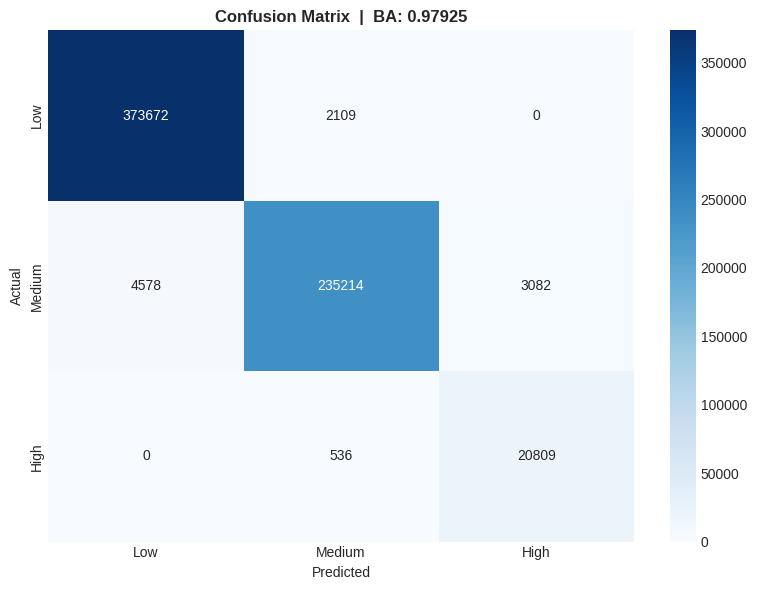

Per-Class Recall
──────────────────────────────
  Low        0.9944
  Medium     0.9685
  High       0.9749
──────────────────────────────
  Mean (BA)  0.97925


In [12]:
#  Post-Training Analysis

opt_preds = (oof_probs * final_w).argmax(axis=1)
cm        = confusion_matrix(y, opt_preds)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", ax=ax,
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"],
)
ax.set_title(f"Confusion Matrix  |  BA: {opt_ba:.5f}", fontweight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

print("Per-Class Recall")
print("─" * 30)
for cls in range(3):
    mask   = y == cls
    recall = (opt_preds[mask] == cls).sum() / mask.sum()
    print(f"  {cfg.INV_MAPPING[cls]:<10} {recall:.4f}")
print("─" * 30)
print(f"  Mean (BA)  {opt_ba:.5f}")

In [13]:
# Submission

test_preds = (final_test_probs * final_w[np.newaxis, :]).argmax(axis=1)
sub        = pd.DataFrame({
    "id":       test["id"],
    cfg.TARGET: [cfg.INV_MAPPING[p] for p in test_preds],
})

sub.to_csv("submission_xgb.csv", index=False)
print("submission_xgb.csv saved")
print(sub[cfg.TARGET].value_counts().to_string())

submission_xgb.csv saved
Irrigation_Need
Low       159433
Medium    100263
High       10304


In [14]:
# ── OOF predictions (competition rows only) ──────────────────────────────────
oof_df = pd.DataFrame({
    "id":       train_raw["id"].values,
    cfg.TARGET: [cfg.INV_MAPPING[p] for p in opt_preds[:n_comp]],
})
oof_df.to_csv("oof_predictions.csv", index=False)
print("oof_predictions.csv saved")

oof_predictions.csv saved
